In [1]:
import os 
import glob
import shutil
import numpy as np

In [2]:
import sys
sys.path.append('/home/duy/NCKH/Retinal-vessels-segmentation/')
from utils import *

In [3]:
import matplotlib.pyplot as plt

In [4]:
images = sorted(glob.glob('/home/duy/NCKH/Retinal-vessels-segmentation/data/DRIVE/*/images/*'))
masks = sorted(glob.glob('/home/duy/NCKH/Retinal-vessels-segmentation/data/DRIVE/*/mask/*'))

In [28]:
np.array(Image.open(masks[0]),dtype=np.uint8)

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(960, 999), dtype=uint8)

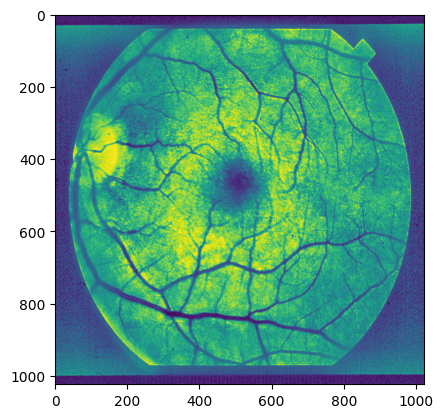

In [74]:
plt.imshow(cv2.resize(preprocessing_img(images[2]),(1024,1024),cv2.INTER_LANCZOS4))

In [19]:
import matplotlib.pyplot as plt
import numpy as np
import cv2 

In [36]:
v_0 =  cv2.imread("/home/duy/Visualization/Method_1_normal/chasedb/v_cat_0.png",1)
v_0.shape

(9216, 1024, 3)

In [37]:
def convert_v2h(image):
    h,w = image.shape[:2]
    img_lst= []
    for i in range(0,h,w):
        img_lst.append(image[i:i+w,:,:])
    # print(np.array(img_lst[3:])[[-1,-4,-3,-5,-6,-2]].shape)
    sorted_lst = np.concatenate([np.array(img_lst[:3]), np.array(img_lst[3:])[[-1,-4,-3,-5,-6,-2]]],0)
    return np.concatenate(sorted_lst,1).astype(np.uint8)

In [38]:
from PIL import Image

im = Image.fromarray(convert_v2h(v_0)[:,:,::-1])
im.save("/home/duy/Visualization/Method_1_normal/chasedb/h_cat_0.png", dpi=(300,300))

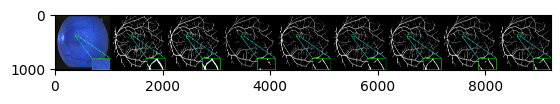

In [10]:
plt.imshow(convert_v2h(v_0))

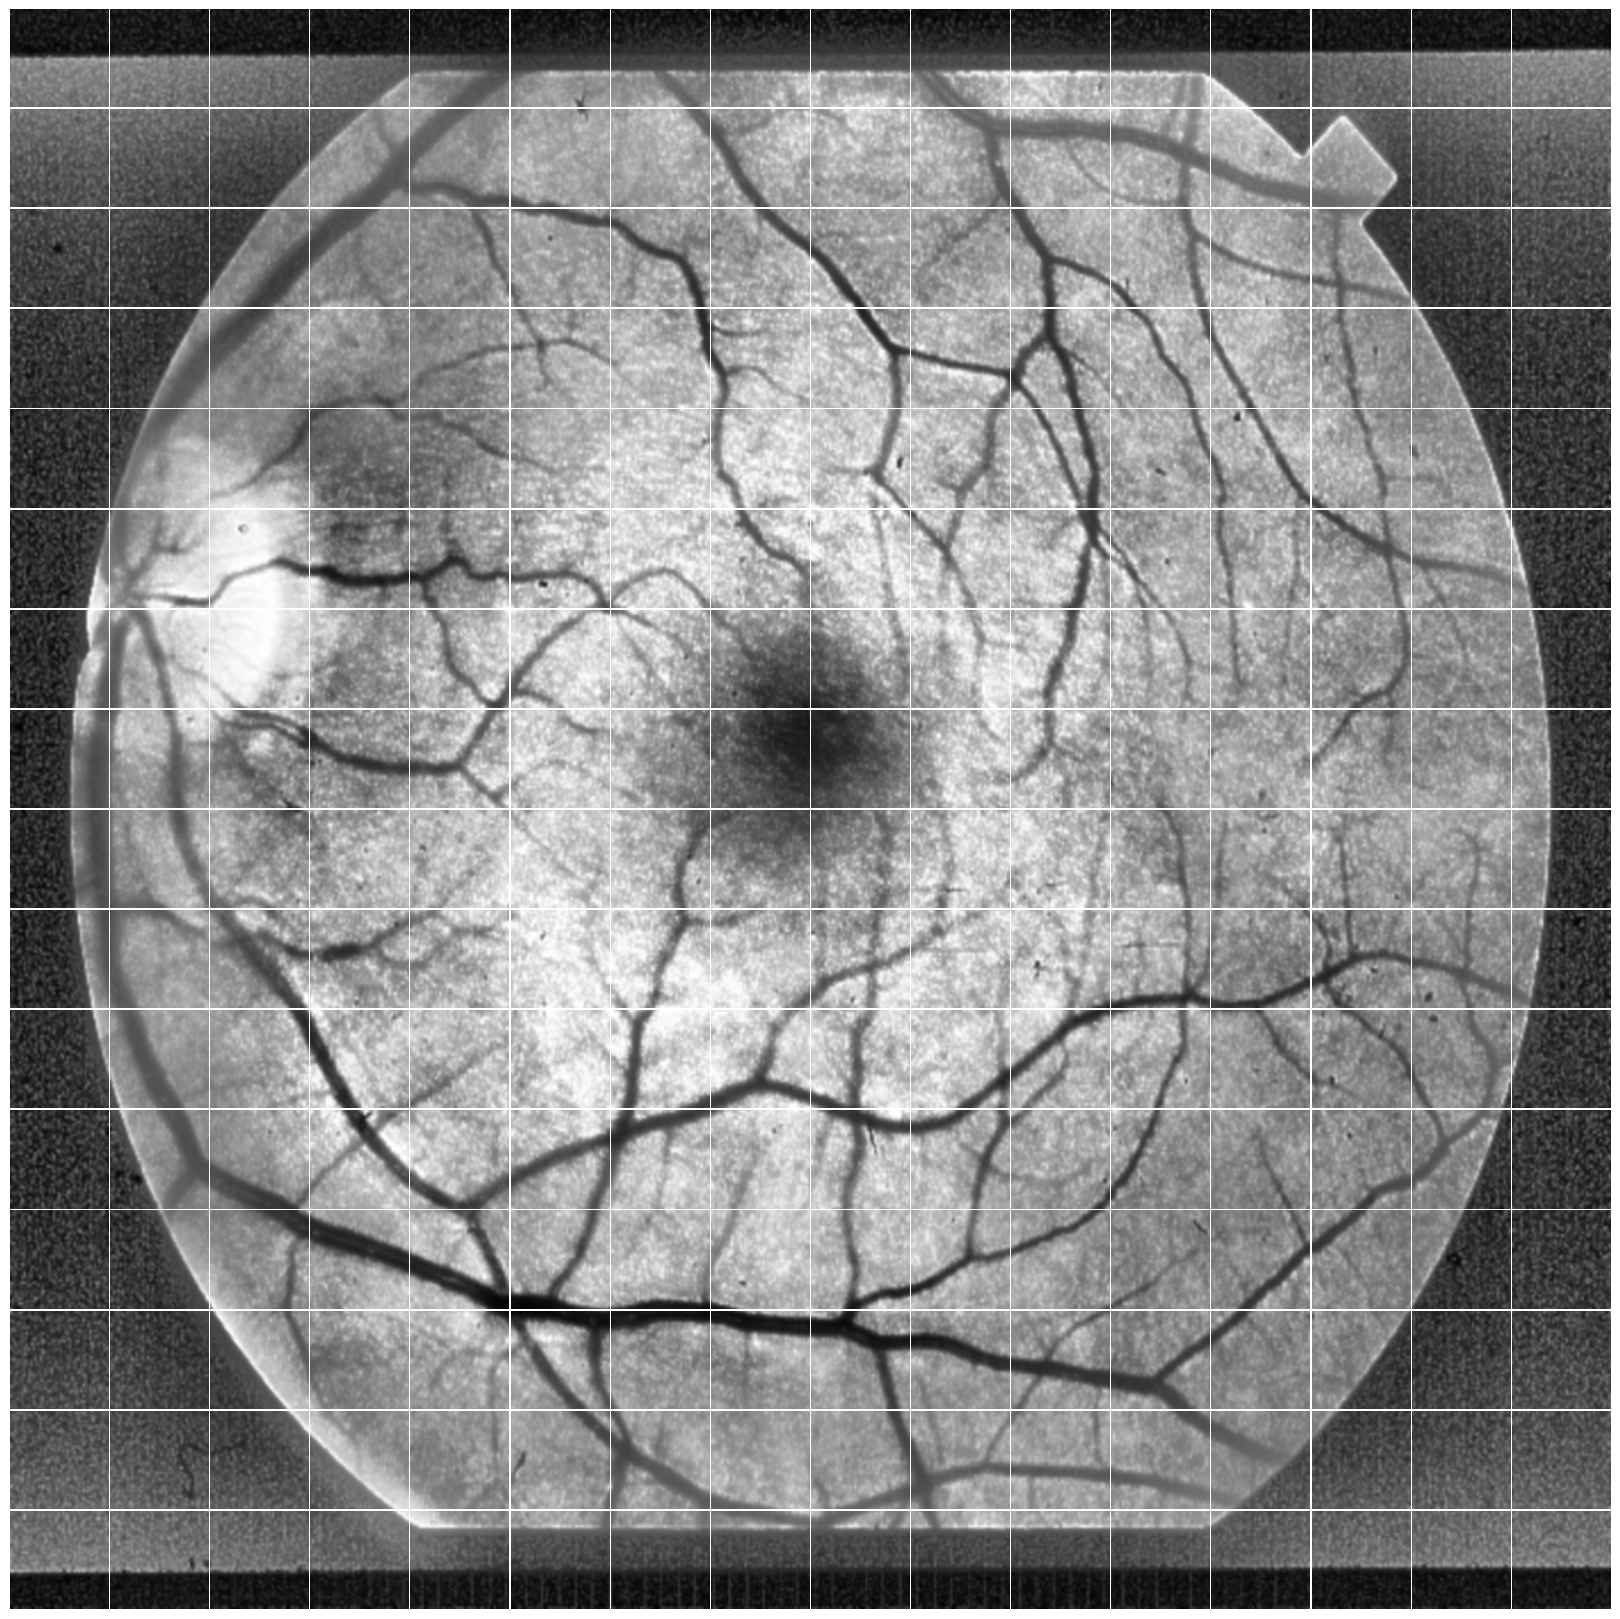

In [ ]:
# import matplotlib.pyplot as plt
# import numpy as np
# images = sorted(glob.glob('/home/duy/NCKH/Retinal-vessels-segmentation/data/STARE_F5/*/images/*'))
# masks = sorted(glob.glob('/home/duy/NCKH/Retinal-vessels-segmentation/data/STARE_F5/*/mask/*'))
# # Giả sử img đã được resize (448, 640)

# img = cv2.resize(preprocessing_img(images[2]),(1024,1024),cv2.INTER_LANCZOS4)
# # 1. Cố định kích thước figure và loại bỏ padding mặc định
# fig, ax = plt.subplots(16, 16, figsize=(16,16), 
#                        gridspec_kw={'wspace': 0.02, 'hspace': 0.02})

# # 2. Sử dụng constrained_layout hoặc subplots_adjust để ép sát các cạnh
# fig.subplots_adjust(left=0, right=1, top=1, bottom=0)
# for i in range(0, 1024, 64):
#     for j in range(0, 1024, 64):
#         row, col = i//64, j//64
#         r=0
#         # Logic ngưỡng (threshold) 22 bạn
#         # r = 90 if (i==0 and j ==0) or (i==0 and j ==960) else 22
#         patch = np.where(img[i:i+64, j:j+64] < r, 0, img[i:i+64, j:j+64])
        
#         ax[row, col].imshow(patch, cmap='gray', aspect='auto',vmin=0, vmax=255, interpolation='bicubic')
#         ax[row, col].axis('off')
# plt.savefig('result_300dpi_chasedb_2.png', 
#             dpi=300, 
#             bbox_inches='tight', 
#             pad_inches=0, 
#             transparent=False)
# plt.show()

In [6]:
# import torch
# import torch.nn as nn
import numpy as np
import cv2
from utils import *
from PIL import Image
import glob
import matplotlib.pyplot as plt
# import albumentations as A
# from albumentations.pytorch import ToTensorV2
# from torch.utils.data import Dataset,DataLoader,random_split
# import torch.nn.functional as F

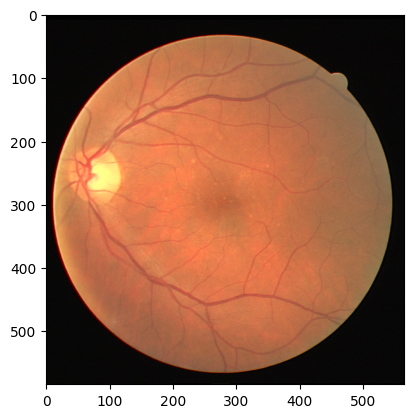

In [7]:
plt.imshow(Image.open('/home/duy/NCKH/Retinal-vessels-segmentation/data/DRIVE/training/images/21_training.tif'))

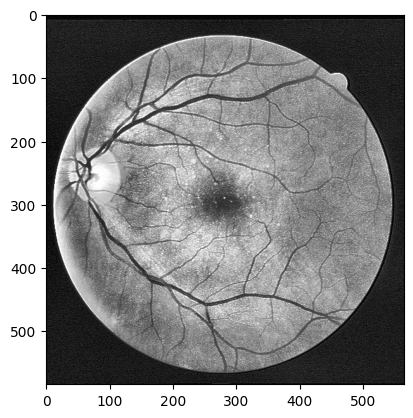

In [8]:
plt.imshow(preprocessing_img('/home/duy/NCKH/Retinal-vessels-segmentation/data/DRIVE/training/images/21_training.tif'),cmap='gray')

In [10]:
from torchvision import transforms as T

In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [61]:
image  = T.ToTensor()(Image.open('/home/duy/NCKH/Retinal-vessels-segmentation/data/DRIVE/training/mask/21_manual1.gif'))

In [13]:
image.shape

torch.Size([1, 584, 565])

In [19]:
64*64

4096

In [45]:
F.pad(image,(0,75,0,56)).shape

torch.Size([1, 640, 640])

In [62]:
patches = F.unfold(F.pad(image,(0,75,0,56)),(64,64),stride=64).transpose(-1,-2).view(-1,64,64)

In [1]:
import numpy as np

In [ ]:
def inc (n,k):
    k_v=k
    n_s = list(str(n))
    while(k_v>0 and int(n_s[0])<9):
        tmp=int(n_s[0])+1
        k_v-=1
        n_s[0]=str(tmp)
    while(k_v>0 and int(n_s[1])<9):
        tmp=int(n_s[1])+1
        k_v-=1
        n_s[1]=str(tmp)
    while(k_v>0 and int(n_s[2])<9):
        tmp=int(n_s[2])+1
        k_v-=1
        n_s[2]=str(tmp)
    return int(''.join(n_s))
    

In [13]:
inc(205,8)

915

In [3]:
np.array([1,2,3])[[2,1,2]]

array([3, 2, 3])

In [47]:
patches.shape

torch.Size([100, 64, 64])

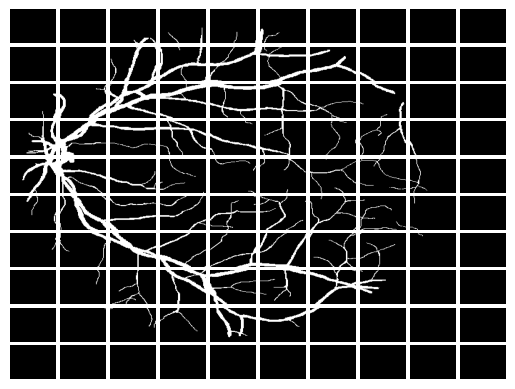

In [64]:
fig,ax = plt.subplots(10,10)
for i,p in enumerate(patches):
    # print(p)
    ax[i//10,i%10].imshow((p*255).numpy().astype(np.uint8),cmap='gray', aspect='auto')
    ax[i//10,i%10].axis(False)
    # plt.imshow(p.numpy().astype(np.uint8))
plt.subplots_adjust(wspace=0.1, hspace=0.1)
plt.show()
plt.show()

In [4]:
# def convert_gray(image,weigh=np.array([0.299, 0.587, 0.114])):
#     image=image.astype(np.float64)
#     gray_img = image*weigh
#     return np.sum(gray_img,-1).astype(np.uint8)

# def sobel_transform(image):
#     blur_img=cv2.GaussianBlur(image,(5,5),1)
#     sb_x =np.abs(cv2.Sobel(blur_img,-1,1,0))
#     sb_y =np.abs(cv2.Sobel(blur_img,-1,0,1))
#     sb = (sb_x+sb_y)/2
#     return sb

# def apply_gamma_correction(image, gamma=1.0):
#     image_normalized = image / 255.0
#     gamma_corrected = np.power(image_normalized, gamma)
#     gamma_corrected = np.uint8(gamma_corrected * 255)

#     return gamma_corrected

# def preprocessing_img(path):
#     img=np.array(Image.open(path).convert('RGB'),dtype=np.uint8)
#     gray_img = convert_gray(img)
#     clahe = cv2.createCLAHE(2,(8,8))
#     clahe_img = clahe.apply(gray_img)
#     out = apply_gamma_correction(clahe_img,1.5)
#     return out

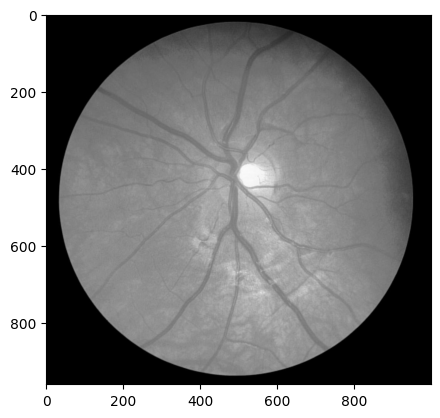

In [5]:
plt.imshow(cv2.imread('/home/duy/NCKH/Retinal-vessels-segmentation/data/CHASEDB_1/test/images/Image_11L.jpg',0),cmap='gray')

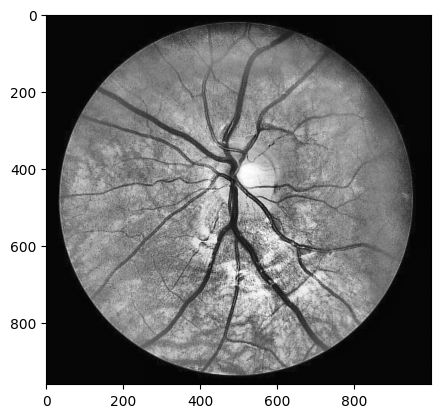

In [6]:
plt.imshow(preprocessing_img('/home/duy/NCKH/Retinal-vessels-segmentation/data/CHASEDB_1/test/images/Image_11L.jpg'),cmap='gray')

In [7]:
a

NameError: name 'a' is not defined

# Define Dataset Class and DataLoader

In [ ]:
class CustomDataset(Dataset):
    def __init__(self,img_paths,mask_paths,img_transforms=None):
        super().__init__()
        self.img_paths = img_paths
        self.mask_paths = mask_paths
        self.img_transforms = img_transforms
    def __len__(self):
        return len(self.img_paths)
    def __getitem__(self, index):
        img_path  = self.img_paths[index]
        mask_path = self.mask_paths[index]
        img  = np.array(Image.open(img_path).convert('RGB'),dtype=np.uint8)[:,:,1]
        mask = (np.array(Image.open(mask_path),dtype=np.uint8)[:,:,0]/255).astype(np.uint8)
        if self.img_transforms is not None:
            transform =  self.img_transforms(image = img,mask=mask)
            t_image  = transform['image']
            t_mask =  transform['mask']
        else:
            raise Exception('Transforms is compulsory')
        
        return {
            'image':t_image,
            'mask':t_mask,
        }

**Split to train test**

In [ ]:
train_image_paths =  sorted(glob.glob('/home/ubuntu/DuyPham/five/FIVES A Fundus Image Dataset for AI-based Vessel Segmentation/FIVES A Fundus Image Dataset for AI-based Vessel Segmentation/train/Original/*png'))
test_image_paths =   sorted(glob.glob('/home/ubuntu/DuyPham/five/FIVES A Fundus Image Dataset for AI-based Vessel Segmentation/FIVES A Fundus Image Dataset for AI-based Vessel Segmentation/test/Original/*png'))

train_mask_paths = sorted(glob.glob('/home/ubuntu/DuyPham/five/FIVES A Fundus Image Dataset for AI-based Vessel Segmentation/FIVES A Fundus Image Dataset for AI-based Vessel Segmentation/train/Ground truth/*png'))
test_mask_paths =  sorted(glob.glob('/home/ubuntu/DuyPham/five/FIVES A Fundus Image Dataset for AI-based Vessel Segmentation/FIVES A Fundus Image Dataset for AI-based Vessel Segmentation/test/Ground truth/*png'))

**Define train_set and train_image_transforms**

In [ ]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

train_image_transforms = A.Compose(
    [
        A.Resize(256, 256, interpolation=cv2.INTER_AREA),  
        A.Normalize(mean=(0.5), std=(0.5)),
        ToTensorV2(),  
    ],
    # additional_targets={'sobel': 'image', 'image': 'image', 'mask': 'mask'}
)

In [ ]:
def decode(img):
    clone_img = img.clone().squeeze().detach().cpu()
    if len(clone_img.shape) > 2:
        clone_img=clone_img.permute(1,2,0).numpy()
    else:
        clone_img=clone_img.numpy()
    clone_img=clone_img*0.5+0.5
    return (clone_img*255).astype(np.uint8)


In [ ]:

all_train_set=CustomDataset(train_image_paths,train_mask_paths,train_image_transforms)
train_set,val_set=random_split(all_train_set,[0.7,0.3],generator=torch.Generator().manual_seed(42))

In [ ]:
test_set = CustomDataset(test_image_paths,test_mask_paths,train_image_transforms)

In [ ]:
batch_size = 32
train_loader = DataLoader(train_set,batch_size,shuffle=True,num_workers=6,generator=torch.Generator().manual_seed(42))
val_loader = DataLoader(val_set,batch_size,shuffle=True,num_workers=6,generator=torch.Generator().manual_seed(42))
test_loader = DataLoader(test_set,batch_size,shuffle=False)

# Define Model

## Unet

In [ ]:
class DoubleConv(nn.Module):
    def __init__(self, in_channel, out_channel, mid_channel=None):
        super().__init__()
        if not mid_channel:
            mid_channel = out_channel

        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channel, mid_channel, kernel_size=3, padding=1),
            nn.BatchNorm2d(mid_channel),
            nn.ReLU(),
            nn.Conv2d(mid_channel, out_channel, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channel),
            nn.ReLU()
        )

    def forward(self, x):
        return self.double_conv(x)

class DownSampling(nn.Module):
    def __init__(self, in_channel, out_channel):
        super().__init__()
        self.downscaling = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channel, out_channel)
        )

    def forward(self, x):
        return self.downscaling(x)

class UpSampling(nn.Module):
    def __init__(self, in_channel, out_channel):
        super().__init__()

        self.upscaling = nn.ConvTranspose2d(in_channel, in_channel // 2, kernel_size=2, stride=2)
        self.double_conv = DoubleConv(in_channel, out_channel)

    def forward(self, x1, x2): # x1 from ConvTransposed, x2 from Encoder
        x1 = self.upscaling(x1)

        delta_height = x2.size()[2] - x1.size()[2]
        delta_width = x2.size()[3] - x1.size()[3]

        x1 = F.pad(x1, [delta_width // 2, delta_width - delta_width // 2,
                        delta_height // 2, delta_height - delta_height // 2])

        x = torch.cat([x2, x1], dim=1)

        return self.double_conv(x)


class OutConv(nn.Module):
    def __init__(self, in_channel, out_channel):
        super().__init__()
        self.conv = nn.Conv2d(in_channel, out_channel, kernel_size=1)

    def forward(self, x):
        return self.conv(x)

In [ ]:
class UNETModel(nn.Module):
    def __init__(self, n_channel, n_class):
        super().__init__()
        self.n_channel = n_channel
        self.n_class = n_class

        self.first_conv = DoubleConv(n_channel, 64)
        
        self.down1 = DownSampling(64, 128)
        self.down2 = DownSampling(128, 256)
        self.down3 = DownSampling(256, 512)
        self.up2 = UpSampling(512, 256)
        self.up3 = UpSampling(256, 128)
        self.up4 = UpSampling(128, 64)

        self.final_conv = OutConv(64, n_class)

    def forward(self, x):
        x1 = self.first_conv(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x = self.up2(x4, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)

        return self.final_conv(x)

In [ ]:
from torchinfo import summary

In [ ]:
summary(UNETModel(3,1),input_data=(torch.rand(1,3,512,512)))

Layer (type:depth-idx)                        Output Shape              Param #
UNETModel                                     [1, 1, 512, 512]          --
├─DoubleConv: 1-1                             [1, 64, 512, 512]         --
│    └─Sequential: 2-1                        [1, 64, 512, 512]         --
│    │    └─Conv2d: 3-1                       [1, 64, 512, 512]         1,792
│    │    └─BatchNorm2d: 3-2                  [1, 64, 512, 512]         128
│    │    └─ReLU: 3-3                         [1, 64, 512, 512]         --
│    │    └─Conv2d: 3-4                       [1, 64, 512, 512]         36,928
│    │    └─BatchNorm2d: 3-5                  [1, 64, 512, 512]         128
│    │    └─ReLU: 3-6                         [1, 64, 512, 512]         --
├─DownSampling: 1-2                           [1, 128, 256, 256]        --
│    └─Sequential: 2-2                        [1, 128, 256, 256]        --
│    │    └─MaxPool2d: 3-7                    [1, 64, 256, 256]         --
│    │    └

In [ ]:
import math
def plot(segmodel,sample,device):
    model = segmodel
    with torch.no_grad():
        model = model.to(device)
        model.eval()
        image,mask=sample.values()
        fig,ax = plt.subplots(1,3,figsize=(12,8))
        pred_mask = model(image.unsqueeze(0).to(device))
        ax[0].imshow(decode(image),cmap='gray')
        ax[0].axis(False)
        ax[0].set_title('Image',c='black')

        ax[1].imshow(mask.cpu())
        ax[1].axis(False)
        ax[1].set_title('True mask',c='black')


        ax[2].imshow(torch.where(pred_mask>0.5,1,0).squeeze().detach().cpu())
        ax[2].axis(False)
        ax[2].set_title('Pred Mask',c='green')
        plt.show()

In [ ]:
device = 'cuda:1' if torch.cuda.is_available() else 'cpu'

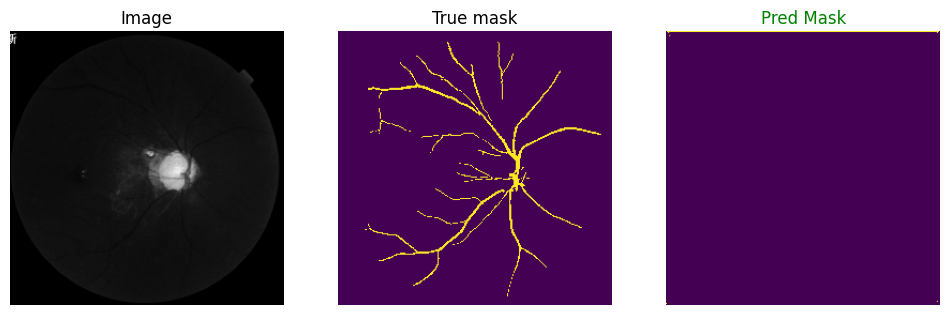

In [ ]:
plot(nn.Sequential(UNETModel(1,1),nn.Sigmoid()),test_set[1],device)

## UNet PP

In [ ]:
class DoubleConvolution(nn.Module):
    def __init__(self, in_channels, out_channels, mid_channels=None):
        super().__init__()
        if not mid_channels:
            mid_channels = out_channels

        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, mid_channels, kernel_size=3, padding='same'),
            nn.BatchNorm2d(mid_channels),
            nn.Conv2d(mid_channels, out_channels, kernel_size=3, padding='same'),
            nn.BatchNorm2d(out_channels),
            nn.Mish()
        )

    def forward(self, x):
        return self.double_conv(x)


class OutConvolution(nn.Module):
    def __init__(self, in_channel, out_channel):
        super().__init__()
        self.conv = nn.Conv2d(in_channel, out_channel, kernel_size=1)

    def forward(self, x):
        return self.conv(x)


class DownScaling(nn.Module):
    def __init__(self, in_channel, out_channel):
        super().__init__()
        self.downscaling = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConvolution(in_channel, out_channel)
        )

    def forward(self, x):
        return self.downscaling(x)


class UpScaling(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.up = nn.Sequential(
            nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2),
            nn.Mish()
        )
    def forward(self, x):
        return self.up(x)


class Concat_and_Conv_Layer(nn.Module):
    def __init__(self, in_channels, out_channels, dim=1):
        super().__init__()
        self.dim = dim
        self.conv = DoubleConvolution(in_channels, out_channels)

    def forward(self, *inputs):
        conv_input = torch.cat(inputs, dim=self.dim)
        output = self.conv(conv_input)
        return output

In [ ]:
class UNET_PP(nn.Module):
    def __init__(self, n_channels, n_classes):
        super().__init__()

        self.n_channels = n_channels
        self.n_classes = n_classes

        # Backbone
        self.down_00 = DoubleConvolution(self.n_channels, 64)             # Output: 64 channels
        self.down_10 = DownScaling(64, 128)                                 # Output: 128 channels, resolution halved
        self.up_10   = UpScaling(128, 64)                                   # Up: 128 -> 64
        self.down_20 = DownScaling(128, 256)                                # Output: 256 channels
        self.up_20   = UpScaling(256, 128)                                  # Up: 256 -> 128
        self.down_30 = DownScaling(256, 512)                                # Output: 512 channels
        self.up_30   = UpScaling(512, 256)                                  # Up: 512 -> 256
        self.down_40 = DownScaling(512, 1024)                               # Output: 1024 channels
        self.up_40   = UpScaling(1024, 512)                                 # Up: 1024 -> 512

        # First Dense Layer
        self.cat_01 = Concat_and_Conv_Layer(64*2, 64)                       # 64+64 = 128 -> 64
        self.cat_11 = Concat_and_Conv_Layer(128*2, 128)                     # 128+128 = 256 -> 128
        self.cat_21 = Concat_and_Conv_Layer(256*2, 256)                     # 256+256 = 512 -> 256

        # Second Dense Layer
        self.cat_02 = Concat_and_Conv_Layer(64*2 + 64, 128)                 # x_00 (64), x_01 (64), up_11(x_11) (64) = 192 -> 128
        self.up_11  = UpScaling(128, 64)                                    # Up: 128 -> 64
        self.cat_12 = Concat_and_Conv_Layer(128*2 + 128, 256)               # x_10 (128), x_11 (128), up_21(x_21) (128) = 384 -> 256
        self.up_21  = UpScaling(256, 128)                                   # Up: 256 -> 128

        # Third Dense Layer
        self.cat_03 = Concat_and_Conv_Layer(320, 512)                       # x_00 (64) + x_01 (64) + x_02 (128) + up_12(x_12) (64) = 320 channels
        self.up_12  = UpScaling(256, 64)                                    # Up: 256 -> 64

        # Last Layer
        self.cat_31 = Concat_and_Conv_Layer(512*2, 512)                     # x_30 (512) + up_40(x_40) (512) = 1024 -> 512
        self.up_31  = UpScaling(512, 256)                                   # Up: 512 -> 256
        self.cat_22 = Concat_and_Conv_Layer(256*3, 256)                     # x_20 (256) + x_21 (256) + up_31(x_31) (256) = 768 -> 256
        self.cat_13 = Concat_and_Conv_Layer(128*3 + 256, 128)               # x_10 (128) + x_11 (128) + x_12 (256) + up_22(x_22) (128) = 640 -> 128
        self.up_22  = UpScaling(256, 128)                                   # Up: 256 -> 128
        self.cat_04 = Concat_and_Conv_Layer(64*3 + 128 + 512, 64)           # x_00 (64) + x_01 (64) + x_02 (128) + x_03 (512) + up_13(x_13) (64) = 832 -> 64
        self.up_13  = UpScaling(128, 64)                                    # Up: 128 -> 64

        # Output
        self.output_conv = OutConvolution(64, self.n_classes)

    def forward(self, x):
        # Backbone forward
        x_00 = self.down_00(x)         # [B, 64, H, W]
        x_10 = self.down_10(x_00)      # [B, 128, H/2, W/2]
        x_20 = self.down_20(x_10)      # [B, 256, H/4, W/4]
        x_30 = self.down_30(x_20)      # [B, 512, H/8, W/8]
        x_40 = self.down_40(x_30)      # [B, 1024, H/16, W/16]

        # First Dense Layer
        x_01 = self.cat_01(x_00, self.up_10(x_10))      # [B, 64, H, W]
        x_11 = self.cat_11(x_10, self.up_20(x_20))        # [B, 128, H/2, W/2]
        x_21 = self.cat_21(x_20, self.up_30(x_30))        # [B, 256, H/4, W/4]

        # Second Dense Layer
        x_02 = self.cat_02(x_00, x_01, self.up_11(x_11))  # [B, 128, H, W]
        x_12 = self.cat_12(x_10, x_11, self.up_21(x_21))  # [B, 256, H/2, W/2]

        # Third Dense Layer
        x_03 = self.cat_03(x_00, x_01, x_02, self.up_12(x_12))  # [B, 512, H, W]

        # Last Layer
        x_31 = self.cat_31(x_30, self.up_40(x_40))              # [B, 512, H/8, W/8]
        x_22 = self.cat_22(x_20, x_21, self.up_31(x_31))         # [B, 256, H/4, W/4]
        x_13 = self.cat_13(x_10, x_11, x_12, self.up_22(x_22))   # [B, 128, H/2, W/2]
        x_04 = self.cat_04(x_00, x_01, x_02, x_03, self.up_13(x_13))  # [B, 64, H, W]

        # Output
        output = self.output_conv(x_04)
        return output

In [ ]:
summary(UNET_PP(3,1),input_data=(torch.rand(1,3,512,512)))

Layer (type:depth-idx)                        Output Shape              Param #
UNET_PP                                       [1, 1, 512, 512]          --
├─DoubleConvolution: 1-1                      [1, 64, 512, 512]         --
│    └─Sequential: 2-1                        [1, 64, 512, 512]         --
│    │    └─Conv2d: 3-1                       [1, 64, 512, 512]         1,792
│    │    └─BatchNorm2d: 3-2                  [1, 64, 512, 512]         128
│    │    └─Conv2d: 3-3                       [1, 64, 512, 512]         36,928
│    │    └─BatchNorm2d: 3-4                  [1, 64, 512, 512]         128
│    │    └─Mish: 3-5                         [1, 64, 512, 512]         --
├─DownScaling: 1-2                            [1, 128, 256, 256]        --
│    └─Sequential: 2-2                        [1, 128, 256, 256]        --
│    │    └─MaxPool2d: 3-6                    [1, 64, 256, 256]         --
│    │    └─DoubleConvolution: 3-7            [1, 128, 256, 256]        221,952
├─Down

# Train

## Unet

**Define Loss**

In [ ]:
class CustomSegLoss(nn.Module):
    def __init__(self,alpha=1):
        super().__init__()
        self.alpha=alpha
    def forward(self,pred,truth):
        
        pred=pred.squeeze()
        truth=truth.squeeze()
        # bce Loss
        # bce = nn.BCELoss()(pred,truth.type(torch.float32))

        # Abe Dice Loss

        erc = torch.pow(pred,2*(1-(pred**2)))
        abe_diceloss_all = 1-(torch.sum(2*erc*truth)/torch.sum(erc**2 +truth))
        return self.alpha*abe_diceloss_all

In [ ]:
# unet_model =nn.Sequential(UNETModel(3,1),nn.Sigmoid()).to(device)

# unet_model = nn.DataParallel(unet_model,device_ids=[1,2,3,0]) 

In [ ]:
model =nn.Sequential(UNETModel(1,1),nn.Sigmoid()).to(device)
model = nn.DataParallel(model,device_ids=[1,2,3,0]) 

In [ ]:
from torch.optim import Adam
optimizer =Adam(model.parameters(),lr=3e-4,weight_decay=1e-5)
criterion =CustomSegLoss()

In [ ]:
from torchmetrics.classification import BinaryF1Score,AUROC, Recall, Specificity,BinaryJaccardIndex
def eval_for_seg(model,val_loader,device):
    with torch.no_grad():
        model.eval()
        truth_label=[]
        pred_label=[]
        pred_probs=[]
        for sample in val_loader:
            image,mask=sample.values()
            
            image=image.to(device)
            mask=mask.to(device)
            prob = model(image)
            pred_mask = torch.where(prob>0.5,1,0).cpu().flatten()
            pred_probs.extend(prob.detach().cpu().flatten().numpy().tolist()) 
            truth_label.extend(mask.flatten().tolist())
            pred_label.extend(pred_mask.detach().numpy().tolist())
        pred_probs=torch.tensor(pred_probs).to(device)
        truth_label=torch.tensor(truth_label).to(device)
        pred_label= torch.tensor(pred_label).to(device)
        return BinaryF1Score().to(device)(pred_label,truth_label).item(),\
            Recall(task='binary').to(device)(pred_label,truth_label).item(),\
            Specificity(task='binary').to(device)(pred_label,truth_label).item(),\
            AUROC(task='binary').to(device)(pred_probs,truth_label).item(),\
            BinaryJaccardIndex().to(device)(pred_label,truth_label).item()

In [ ]:
from tqdm import tqdm
def train_one_epoch_for_seg(model,train_loader,optimizer,criterion,device):
    model.train()
    training_loss = 0 
    for sample in tqdm(train_loader):
        image,mask=sample.values()
        image=image.to(device)
        mask=mask.to(device)

        pred_mask = model(image)

        loss = criterion(pred_mask,mask)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        training_loss+=loss.item()
    return training_loss/len(train_loader)


In [ ]:
def train_seg(epochs,model,train_loader,val_loader,optimizer,criterion,device,save_dir='./best_seg_model.pth'):
    best_val_f1=0
    lst_f1=[]
    lst_loss=[]
    lst_recall=[]
    lst_spe=[]
    lst_auc=[]
    lst_iou=[]
    for e in tqdm(range(epochs)):
        training_loss=train_one_epoch_for_seg(model,train_loader,optimizer,criterion,device)
        val_f1, val_recall, val_specificity, val_auroc,iou = eval_for_seg(model,val_loader,device)
        print(f'Epoch [{e}/{epochs}]: training loss {training_loss} val f1 {val_f1} val recall {val_recall} val specificity {val_specificity} val auroc {val_auroc} val iou {iou}')
        if best_val_f1 < val_f1:
            best_val_f1=val_f1
            if isinstance(model,nn.DataParallel):
                torch.save(model.module.state_dict(), save_dir)
            else:
                torch.save(model.state_dict(), save_dir)
            print('===>Save model')
        if e%10==0:
            print(training_loss)
            plot(model,test_set[0],device)
        lst_f1.append(val_f1)
        lst_loss.append(training_loss)
        lst_recall.append(val_recall)
        lst_spe.append(val_specificity)
        lst_auc.append(val_auroc)
        lst_iou.append(iou)
    return {
        'f1':lst_f1,
        'loss':lst_loss,
        'recall':lst_recall,
        'spe':lst_spe,
        'auc':lst_auc,
        'iou':lst_iou,

    }

100%|██████████| 14/14 [00:14<00:00,  1.06s/it]


Epoch [0/30]: training loss 0.5809603333473206 val f1 0.14291611313819885 val recall 0.5783395767211914 val specificity 0.45945098996162415 val auroc 0.48636630177497864 val iou 0.07695727050304413
===>Save model
0.5809603333473206


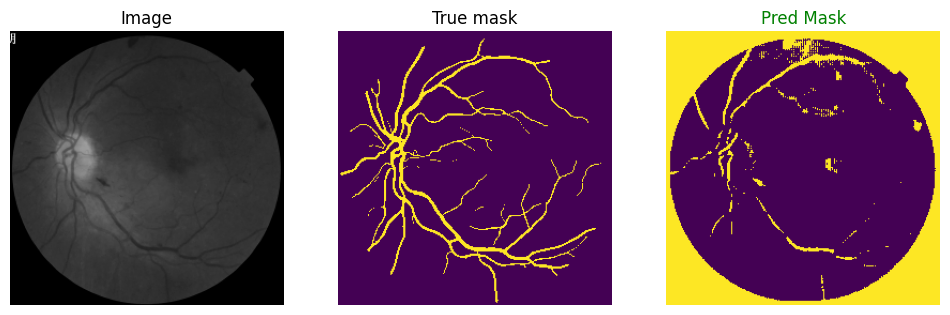

  7%|▋         | 2/30 [00:50<11:55, 25.56s/it]

Epoch [1/30]: training loss 0.36716119732175556 val f1 0.08728047460317612 val recall 0.10456117987632751 val specificity 0.892852246761322 val auroc 0.6620696783065796 val iou 0.04563160985708237


 10%|█         | 3/30 [01:15<11:11, 24.89s/it]

Epoch [2/30]: training loss 0.30325524296079365 val f1 0.43080827593803406 val recall 0.5075119733810425 val specificity 0.9295941591262817 val auroc 0.8541812300682068 val iou 0.2745415270328522
===>Save model


 13%|█▎        | 4/30 [01:40<10:55, 25.21s/it]

...

Epoch [8/30]: training loss 0.14703817878450667 val f1 0.8240718841552734 val recall 0.8482171297073364 val specificity 0.9825447797775269 val auroc 0.9813234806060791 val iou 0.7007842659950256
===>Save model


 33%|███▎      | 10/30 [04:13<08:25, 25.29s/it]

Epoch [9/30]: training loss 0.1374206074646541 val f1 0.8307744264602661 val recall 0.868750274181366 val specificity 0.9815251231193542 val auroc 0.9827750325202942 val iou 0.7105339169502258
===>Save model


100%|██████████| 14/14 [00:14<00:00,  1.00s/it]


Epoch [10/30]: training loss 0.13375540290560042 val f1 0.8255547285079956 val recall 0.8894504904747009 val specificity 0.9779846668243408 val auroc 0.9861768484115601 val iou 0.7029316425323486
0.13375540290560042


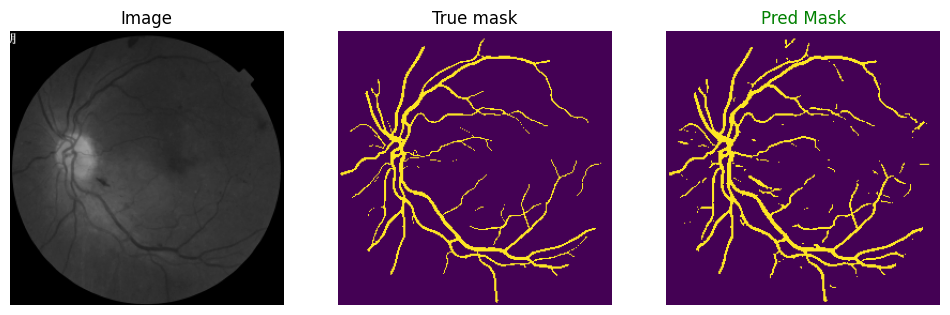

 40%|████      | 12/30 [05:03<07:30, 25.04s/it]

Epoch [11/30]: training loss 0.13592819656644547 val f1 0.8104380369186401 val recall 0.8909664154052734 val specificity 0.9744653105735779 val auroc 0.9782248139381409 val iou 0.6812911629676819


 43%|████▎     | 13/30 [05:28<07:07, 25.15s/it]

Epoch [12/30]: training loss 0.1394191895212446 val f1 0.8418155312538147 val recall 0.8447482585906982 val specificity 0.9865408539772034 val auroc 0.977516770362854 val iou 0.7268406748771667
===>Save model


 47%|████▋     | 14/30 [05:54<06:44, 25.26s/it]

...

Epoch [18/30]: training loss 0.10576694352286202 val f1 0.8704666495323181 val recall 0.865475058555603 val specificity 0.989790141582489 val auroc 0.9884951114654541 val iou 0.7706426978111267


 67%|██████▋   | 20/30 [08:25<04:11, 25.10s/it]

Epoch [19/30]: training loss 0.10302452530179705 val f1 0.8748880624771118 val recall 0.8841891288757324 val specificity 0.9886271953582764 val auroc 0.9902732372283936 val iou 0.777600884437561


100%|██████████| 14/14 [00:15<00:00,  1.10s/it]


Epoch [20/30]: training loss 0.09893653648240226 val f1 0.8726660013198853 val recall 0.9013751745223999 val specificity 0.9863581657409668 val auroc 0.9906128644943237 val iou 0.7740971446037292
0.09893653648240226


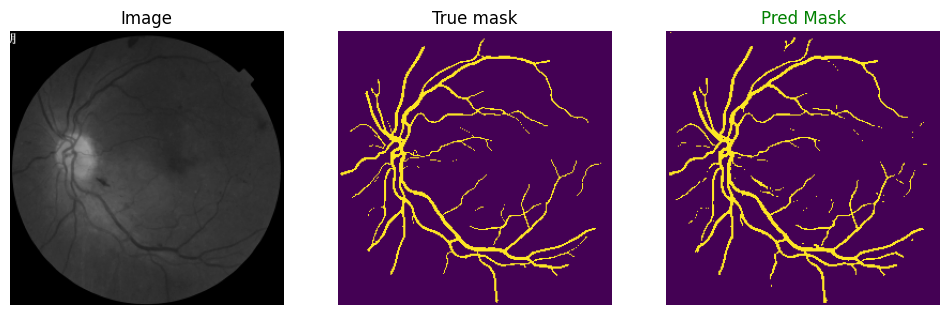

 73%|███████▎  | 22/30 [09:16<03:23, 25.47s/it]

Epoch [21/30]: training loss 0.09545046942574638 val f1 0.879470944404602 val recall 0.9009502530097961 val specificity 0.9877292513847351 val auroc 0.9910109043121338 val iou 0.7848711013793945
===>Save model


 77%|███████▋  | 23/30 [09:42<02:59, 25.61s/it]

Epoch [22/30]: training loss 0.09328011955533709 val f1 0.8822458982467651 val recall 0.8909984827041626 val specificity 0.9893100261688232 val auroc 0.9908037185668945 val iou 0.7893022894859314
===>Save model


 80%|████████  | 24/30 [10:08<02:34, 25.67s/it]

...

Epoch [27/30]: training loss 0.08747764996119908 val f1 0.8864404559135437 val recall 0.8896374702453613 val specificity 0.9902448654174805 val auroc 0.9915525317192078 val iou 0.796042263507843
===>Save model


 97%|█████████▋| 29/30 [12:16<00:25, 25.56s/it]

Epoch [28/30]: training loss 0.08878277029309954 val f1 0.8772825598716736 val recall 0.8766705393791199 val specificity 0.9898832440376282 val auroc 0.9894384741783142 val iou 0.7813920974731445


100%|██████████| 30/30 [12:41<00:00, 25.39s/it]

Epoch [29/30]: training loss 0.09714014189583915 val f1 0.8633753657341003 val recall 0.9116179347038269 val specificity 0.983394980430603 val auroc 0.9883807897567749 val iou 0.7595958709716797


In [ ]:
history=train_seg(30,model,train_loader,val_loader,optimizer,criterion,device)

In [ ]:
import time
torch.cuda.empty_cache()
time.sleep(5)

In [ ]:
import seaborn as sns
import pandas as pd
def plot_history(history):
    long_data = []
    for label, y_values in history.items():
        for x, y in enumerate(y_values):
            if label=='iot':label='iou'
            long_data.append({'label': label, 'x': x, 'y': y})

    df = pd.DataFrame(long_data)


    sns.lineplot(data=df, x='x', y='y', hue='label')
    plt.grid()
    plt.xlabel('Epochs')
    plt.ylabel('Value')
    plt.title('Plot metrics in training process')
    plt.show()

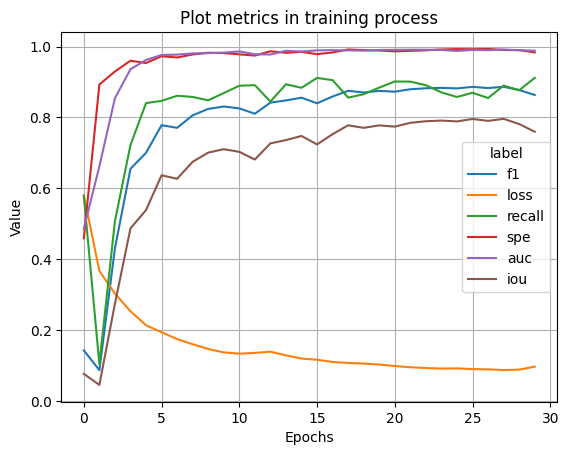

In [ ]:
plot_history(history)

In [ ]:
F

<module 'torch.nn.functional' from '/home/ubuntu/DuyPham/.venv/lib/python3.10/site-packages/torch/nn/functional.py'>

## UNET PP

In [ ]:
unet_pp =nn.Sequential(UNET_PP(3,1),nn.Sigmoid()).to(device)
unet_pp = nn.DataParallel(unet_pp,device_ids=[1,2,3,0]) 

In [ ]:
optimizer_pp =Adam(unet_pp.parameters(),lr=3e-4,weight_decay=1e-5)
criterion_pp =CustomSegLoss()

In [ ]:
history_1=train_seg(30,unet_pp,train_loader,val_loader,optimizer_pp,criterion_pp,device,'./best_seg_model_pp.pth')

  0%|          | 0/30 [00:09<?, ?it/s]


RuntimeError: Caught RuntimeError in replica 0 on device 1.
Original Traceback (most recent call last):
  File "/home/ubuntu/DuyPham/.venv/lib/python3.10/site-packages/torch/nn/parallel/parallel_apply.py", line 97, in _worker
    output = module(*input, **kwargs)
  File "/home/ubuntu/DuyPham/.venv/lib/python3.10/site-packages/torch/nn/modules/module.py", line 1751, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
  File "/home/ubuntu/DuyPham/.venv/lib/python3.10/site-packages/torch/nn/modules/module.py", line 1762, in _call_impl
    return forward_call(*args, **kwargs)
  File "/home/ubuntu/DuyPham/.venv/lib/python3.10/site-packages/torch/nn/modules/container.py", line 240, in forward
    input = module(input)
  File "/home/ubuntu/DuyPham/.venv/lib/python3.10/site-packages/torch/nn/modules/module.py", line 1751, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
  File "/home/ubuntu/DuyPham/.venv/lib/python3.10/site-packages/torch/nn/modules/module.py", l

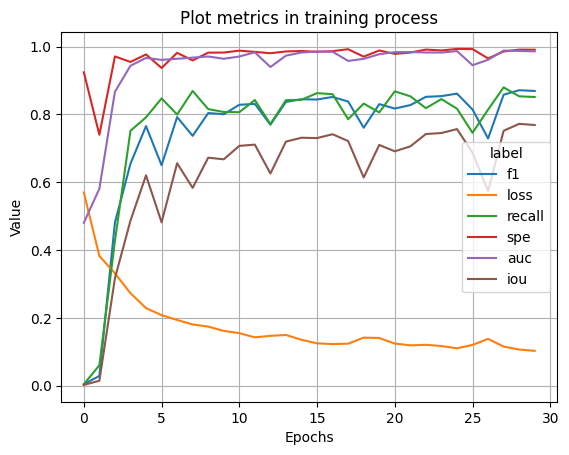

In [ ]:
plot_history(history_1)

# Evaluate

## UNET

**Eval**

In [ ]:
best_model=nn.Sequential(UNETModel(1,1),nn.Sigmoid())
best_model.load_state_dict(torch.load('/home/ubuntu/DuyPham/test_vton_1/notebooks/Duy/best_seg_model.pth',weights_only=True))
best_model.to(device)
best_model=nn.DataParallel(best_model,device_ids=[1,2,3,0])

**Show Random 5 train_image**

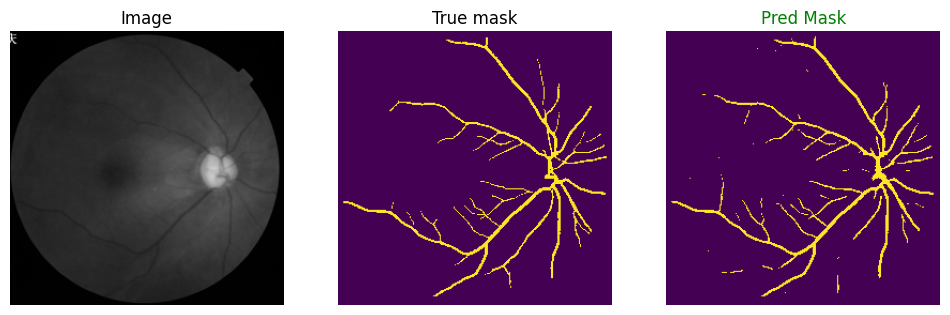

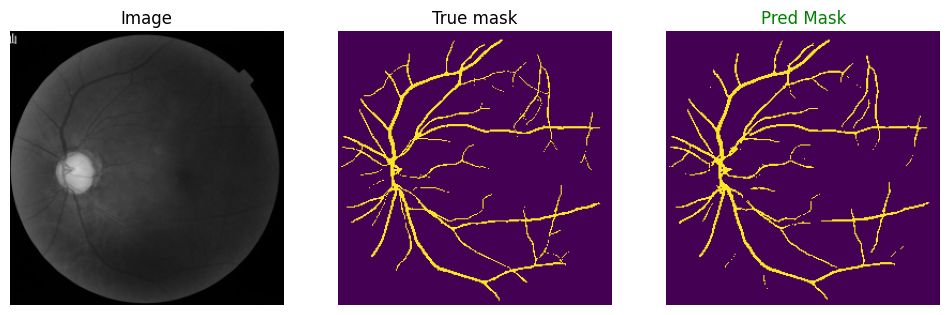

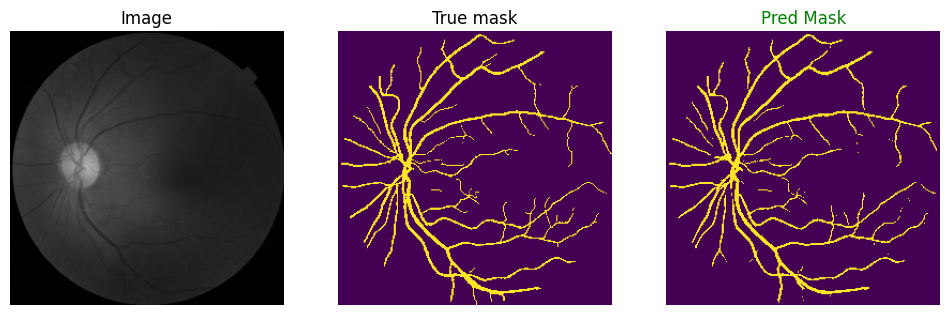

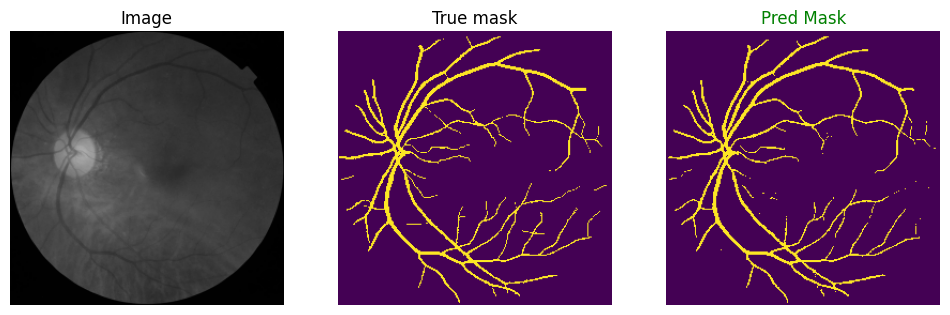

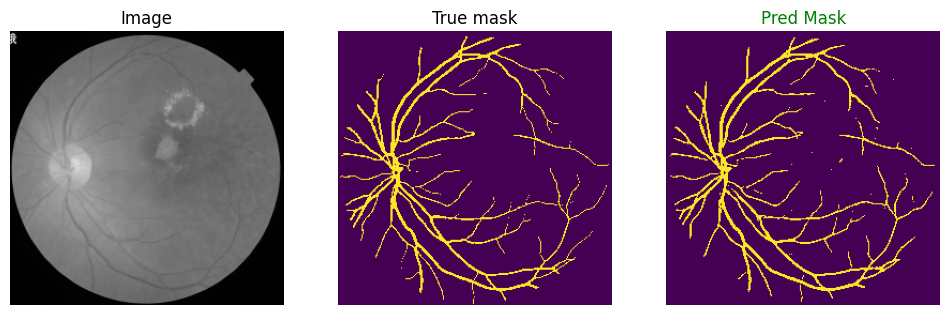

In [ ]:
for i in range(5):
    plot(best_model,train_set[np.random.randint(0,len(test_set))],device)

**Show Random 5 test_image**

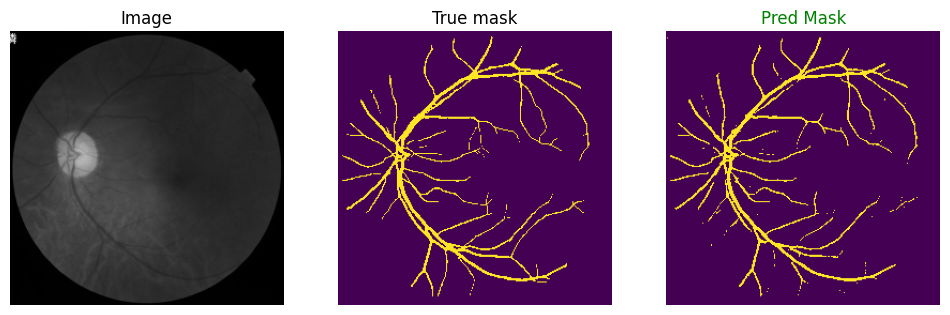

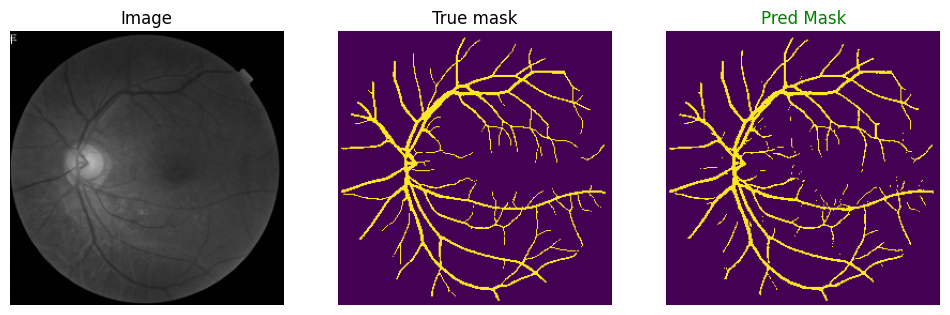

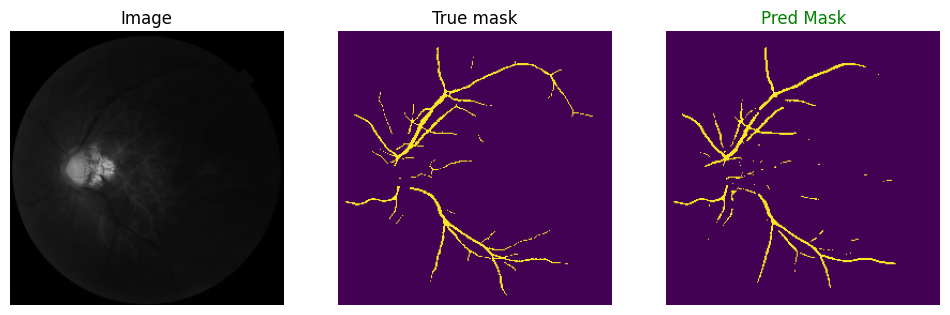

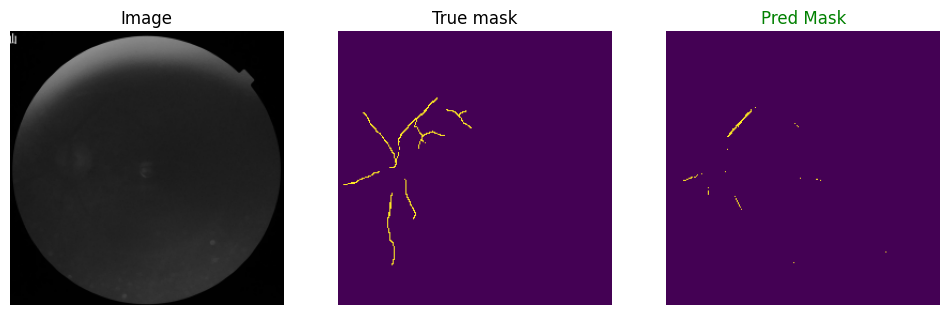

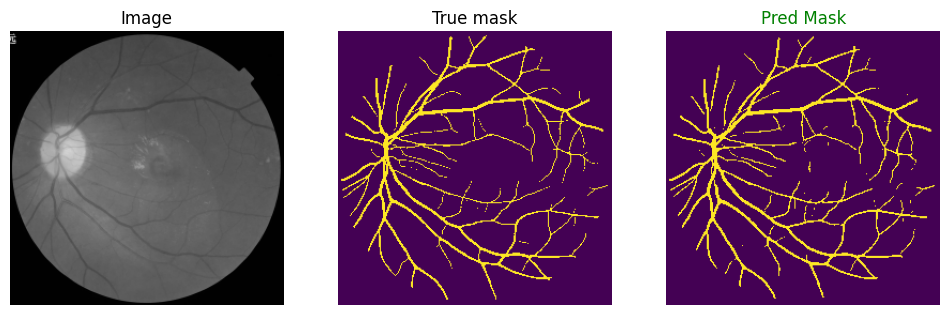

In [ ]:
for i in range(5):
    plot(best_model,test_set[np.random.randint(0,len(test_set))],device)

**Score**

In [ ]:
test_f1, test_recall, test_specificity, test_auroc,test_iou=eval_for_seg(best_model,test_loader,device)

print(f'f1 {test_f1}, recall {test_recall}, spe {test_specificity}, auc {test_auroc}, iou {test_iou}')

f1 0.8654624223709106, recall 0.8607074022293091, spe 0.990131139755249, auc 0.9877772927284241, iou 0.762832760810852


**Show Feature map per encode layers**

In [ ]:
def plot_feature_per_conv(sample,model):
    module_dict = {name: module for name, module in model.named_modules()
             if isinstance(module, (nn.Conv2d,nn.ReLU,nn.BatchNorm2d))}
    len_conv_dict = len({name: module for name, module in model.named_modules()
             if isinstance(module, (nn.Conv2d))})
    tmp=sample['image'].unsqueeze(0)
    i=0
    break_ = (len_conv_dict//2) + (len_conv_dict//2)%2
    break_ = break_ if break_ <=10 else 10
    fig,ax = plt.subplots(2,break_//2,figsize=(14,7))
    for module in module_dict.values():
        module.to('cpu')
        tmp=module(tmp.cpu())
        if isinstance(module,nn.Conv2d):
            ax[i//(break_//2),i%(break_//2)].imshow(torch.sigmoid(torch.max(tmp[0],0).values.detach().cpu())*255,cmap='gray')
            ax[i//(break_//2),i%(break_//2)].axis(False)
            ax[i//(break_//2),i%(break_//2)].set_title(f'Feature map in conv:{i}')
            i+=1
        if i==break_:break
    plt.show()

**Model chua duoc hoc**

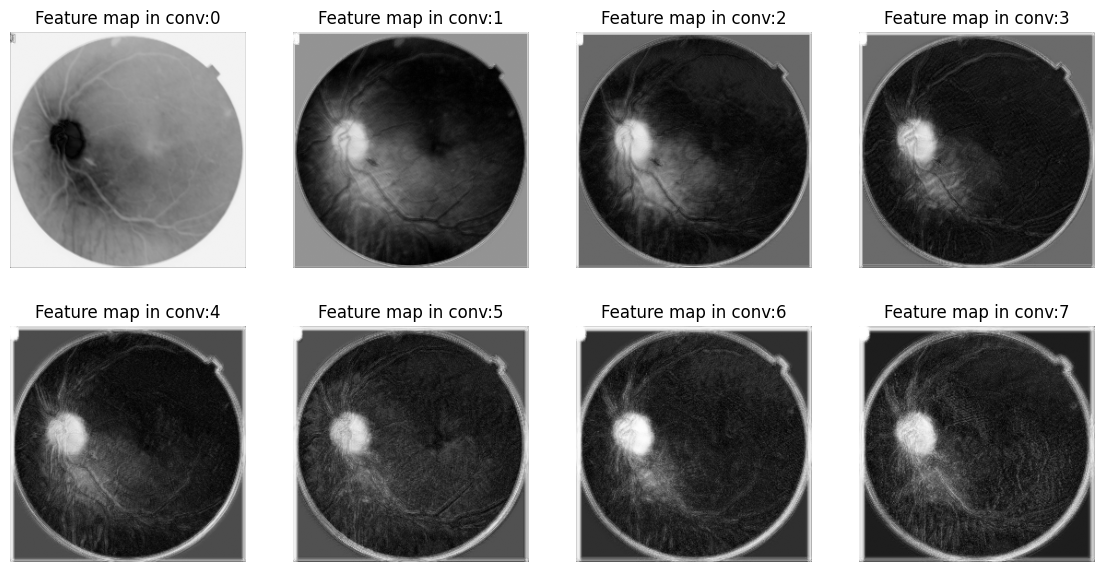

In [ ]:
plot_feature_per_conv(test_set[0],nn.Sequential(UNETModel(3,1),nn.Sigmoid()))

**Model da duoc hoc**

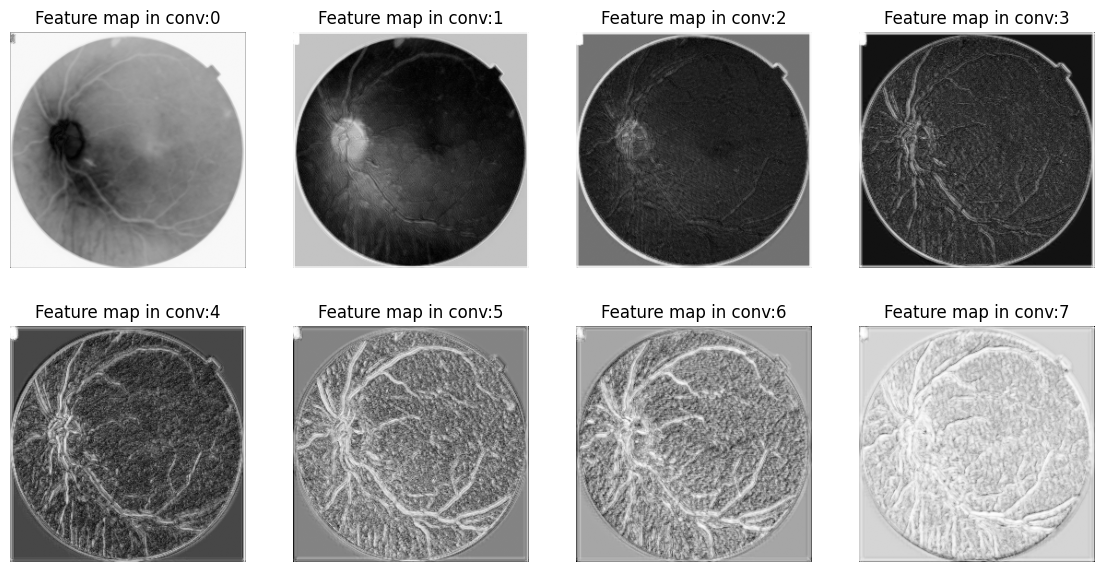

In [ ]:
plot_feature_per_conv(test_set[0],best_model)

## UNET PP

In [ ]:
best_model_pp=nn.Sequential(UNET_PP(3,1),nn.Sigmoid())
best_model_pp.load_state_dict(torch.load('/home/ubuntu/DuyPham/test_vton_1/notebooks/Duy/best_seg_model_pp.pth',weights_only=True))
best_model_pp.to(device)
best_model_pp=nn.DataParallel(best_model_pp,device_ids=[1,2,3,0])

In [ ]:
test_f1, test_recall, test_specificity, test_auroc,test_iou=eval_for_seg(best_model_pp,test_loader,device)

print(f'f1 {test_f1}, recall {test_recall}, spe {test_specificity}, auc {test_auroc}, iou {test_iou}')

f1 0.8460372090339661, recall 0.8202765583992004, spe 0.9908601641654968, auc 0.9818744659423828, iou 0.7331581711769104


**Show random 5 image in test set**

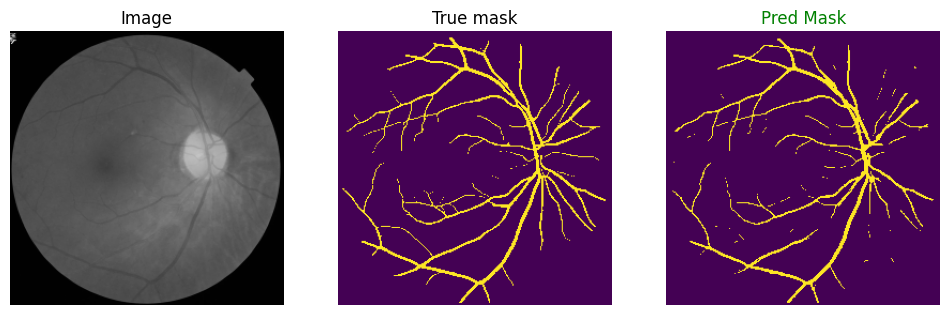

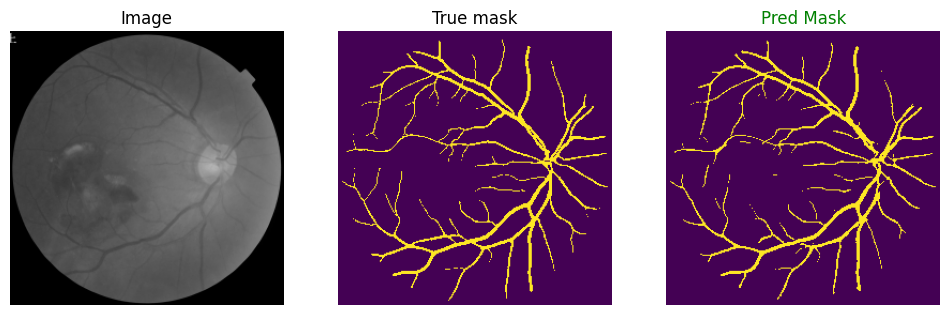

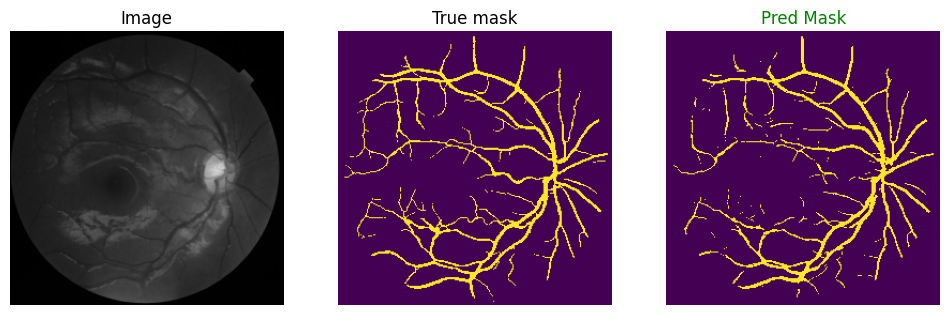

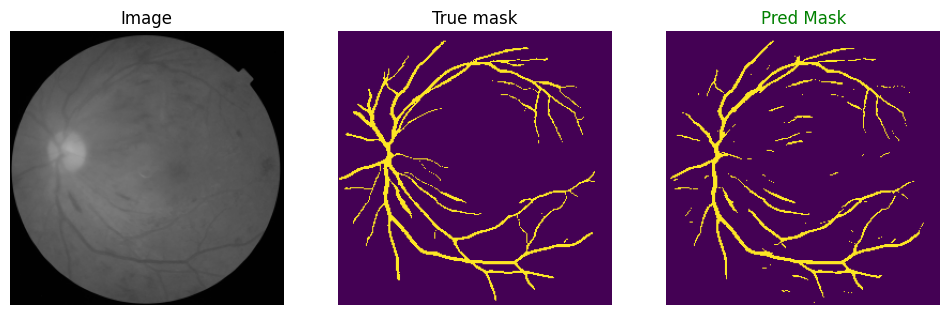

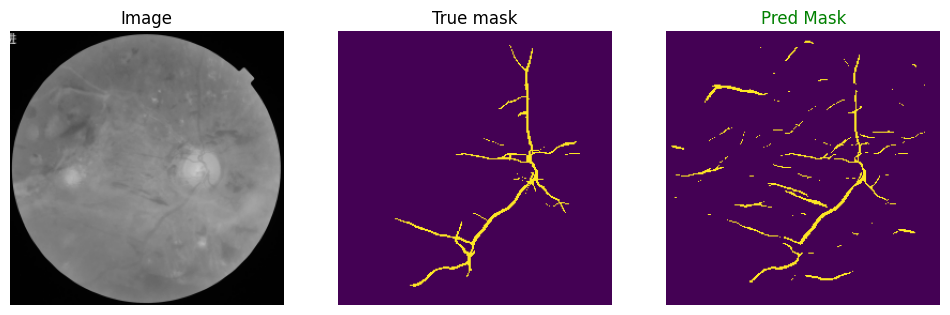

In [ ]:
for i in range(5):
    plot(best_model_pp,test_set[np.random.randint(0,len(test_set))],device)

**Show feature cua model unet pp chua duoc hoc**

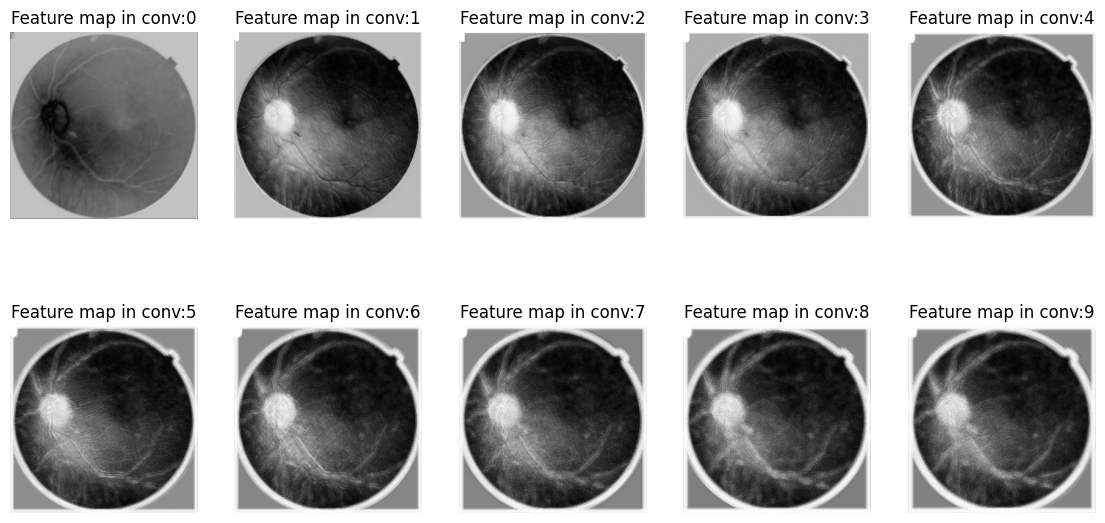

In [ ]:
plot_feature_per_conv(test_set[0],nn.Sequential(UNET_PP(3,1),nn.Sigmoid()))

**Show feature cua model unet pp da duoc hoc**

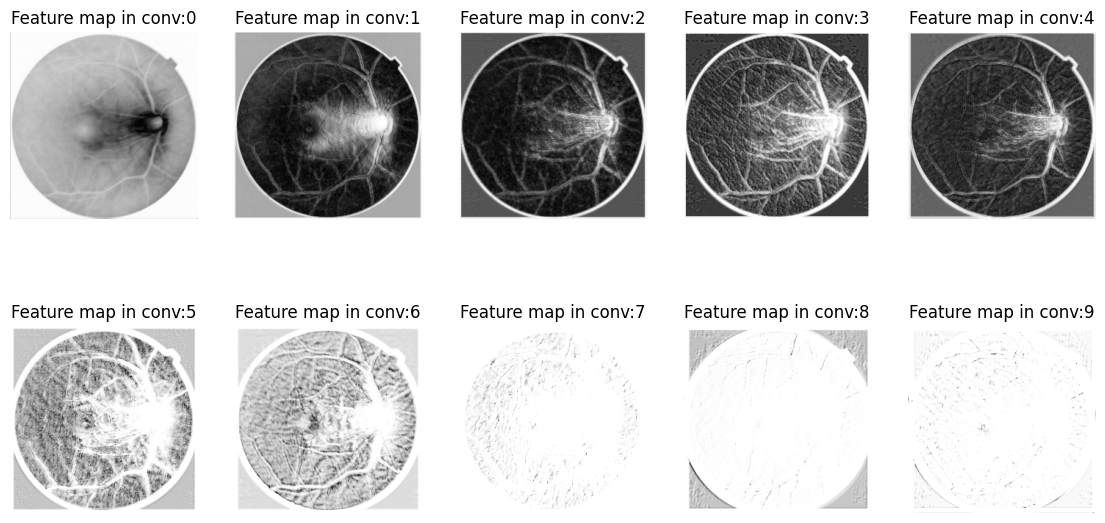

In [ ]:
plot_feature_per_conv(train_set[0],best_model_pp)

# Inference 

In [ ]:
infer_image_path = '/home/ubuntu/DuyPham/test_vton_1/notebooks/Duy/infer_images/Retinal-Image-cf5af98e-640w.jpg'


In [ ]:
infer_tensor=CustomDataset([infer_image_path],[infer_image_path],train_image_transforms)[0]['image'].unsqueeze(0)

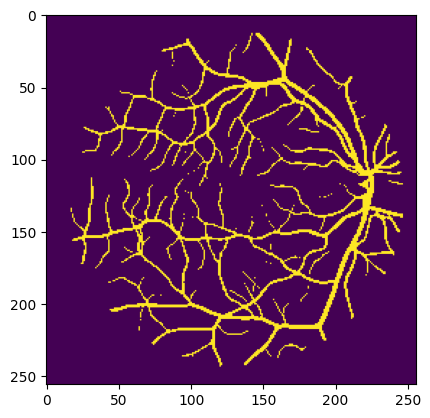

In [ ]:
plt.imshow(torch.where(best_model_pp(infer_tensor.to(device))>0.5,1,0).squeeze().detach().cpu())